In [54]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# 1. Data Collection


In [56]:
from datetime import datetime

now = datetime.now()

# ticker is from yahoo finance, start and end are date range for which we want to download data
ticker = 'AAPL'
start = datetime(now.year - 12, now.month + 4, now.day + 1)
end = datetime(now.year - 2, now.month + 4, now.day + 1)
df = yf.download(ticker, start, end) # sticker is stock symbol
df


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2014-08-07,20.835508,21.159683,20.751707,20.934745,186844000
2014-08-08,20.892849,20.910492,20.570878,20.786996,167460000
2014-08-11,21.168497,21.188345,20.914889,21.009717,146340000
2014-08-12,21.164085,21.364765,21.084695,21.179522,135180000
2014-08-13,21.444164,21.444164,21.179531,21.203789,127664000
...,...,...,...,...,...
2024-07-31,220.375595,222.102246,218.936726,219.740508,50036300
2024-08-01,216.684158,222.757184,215.354446,222.648028,62501000


# 2. Data Exploration and Visualization

In [57]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2014-08-07,20.835508,21.159683,20.751707,20.934745,186844000
2014-08-08,20.892849,20.910492,20.570878,20.786996,167460000
2014-08-11,21.168497,21.188345,20.914889,21.009717,146340000
2014-08-12,21.164085,21.364765,21.084695,21.179522,135180000
2014-08-13,21.444164,21.444164,21.179531,21.203789,127664000


In [58]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-07-31,220.375595,222.102246,218.936726,219.740508,50036300
2024-08-01,216.684158,222.757184,215.354446,222.648028,62501000
2024-08-02,218.172638,223.868591,216.039145,217.468080,105568600
2024-08-05,207.663925,211.861457,194.495764,197.562045,119548600
2024-08-06,205.639572,208.378400,199.526860,203.724392,69660500


In [59]:
type(df)

pandas.DataFrame

In [60]:
df.shape

(2516, 5)

In [61]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [62]:
df.describe() # Statistical summary of the data

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2516.000000,2516.000000,2516.000000,2516.000000,2.516000e+03
mean,85.401831,86.259088,84.470038,85.335697,1.239778e+08
std,60.427022,61.037958,59.767783,60.379803,7.168344e+07
min,20.584818,20.887868,20.386581,20.507344,2.404830e+07
25%,29.932217,30.049656,29.639198,29.857441,7.561260e+07
50%,52.322973,52.847501,51.579811,52.295917,1.049338e+08
75%,144.192097,145.592173,142.351816,144.072224,1.511626e+08
max,233.017853,235.409342,231.301115,234.665098,7.593852e+08


In [63]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [64]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2014-08-07,20.835508,21.159683,20.751707,20.934745,186844000
2014-08-08,20.892849,20.910492,20.570878,20.786996,167460000
2014-08-11,21.168497,21.188345,20.914889,21.009717,146340000
2014-08-12,21.164085,21.364765,21.084695,21.179522,135180000
2014-08-13,21.444164,21.444164,21.179531,21.203789,127664000


In [65]:
df.reset_index()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2014-08-07,20.835508,21.159683,20.751707,20.934745,186844000
1,2014-08-08,20.892849,20.910492,20.570878,20.786996,167460000
2,2014-08-11,21.168497,21.188345,20.914889,21.009717,146340000
3,2014-08-12,21.164085,21.364765,21.084695,21.179522,135180000
4,2014-08-13,21.444164,21.444164,21.179531,21.203789,127664000
...,...,...,...,...,...,...
2511,2024-07-31,220.375595,222.102246,218.936726,219.740508,50036300
2512,2024-08-01,216.684158,222.757184,215.354446,222.648028,62501000
2513,2024-08-02,218.172638,223.868591,216.039145,217.468080,105568600


In [66]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2014-08-07,20.835508,21.159683,20.751707,20.934745,186844000
2014-08-08,20.892849,20.910492,20.570878,20.786996,167460000
2014-08-11,21.168497,21.188345,20.914889,21.009717,146340000
2014-08-12,21.164085,21.364765,21.084695,21.179522,135180000
2014-08-13,21.444164,21.444164,21.179531,21.203789,127664000


Text(0, 0.5, 'Close Price')

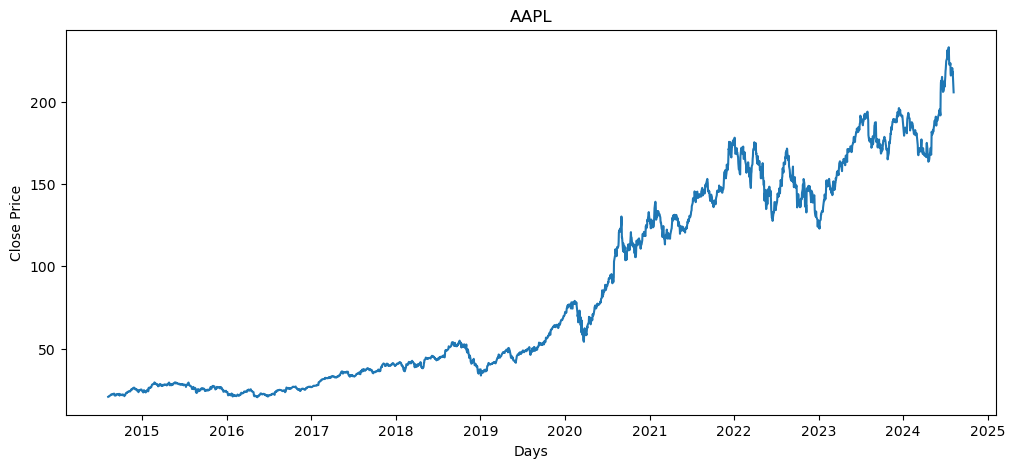

In [67]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close Price')

# 3. Feature Engineering

In [68]:
# 10, 20, 30, 40, 50, 60, 70, 80, 90, 100

# Moving Average (MA) is a commonly used technical indicator in stock analysis. 
# It helps smooth out price data to identify trends over a specific period. 
# The MA of 5 days, for example, would be calculated by taking the average of the closing prices of the last 5 days.
# MA of 5 days ==> null null null null 30 40 

In [69]:
temp_df = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_df[2:7])/5)

50.0


In [70]:
df1 = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [71]:
df1['MA_5'] = df1.rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


100 days Moving Average

In [72]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head()

Price,Close,High,Low,Open,Volume,MA_100
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2014-08-07,20.835508,21.159683,20.751707,20.934745,186844000,NaN
2014-08-08,20.892849,20.910492,20.570878,20.786996,167460000,NaN
2014-08-11,21.168497,21.188345,20.914889,21.009717,146340000,NaN
2014-08-12,21.164085,21.364765,21.084695,21.179522,135180000,NaN
2014-08-13,21.444164,21.444164,21.179531,21.203789,127664000,NaN


In [73]:
df.head(103)

Price,Close,High,Low,Open,Volume,MA_100
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2014-08-07,20.835508,21.159683,20.751707,20.934745,186844000,NaN
2014-08-08,20.892849,20.910492,20.570878,20.786996,167460000,NaN
2014-08-11,21.168497,21.188345,20.914889,21.009717,146340000,NaN
2014-08-12,21.164085,21.364765,21.084695,21.179522,135180000,NaN
2014-08-13,21.444164,21.444164,21.179531,21.203789,127664000,NaN
...,...,...,...,...,...,...
2014-12-26,25.247009,25.364396,24.808471,24.828404,134884000,NaN
2014-12-29,25.229292,25.419767,25.182779,25.202713,110395600,23.279447


Text(0, 0.5, 'Close Price')

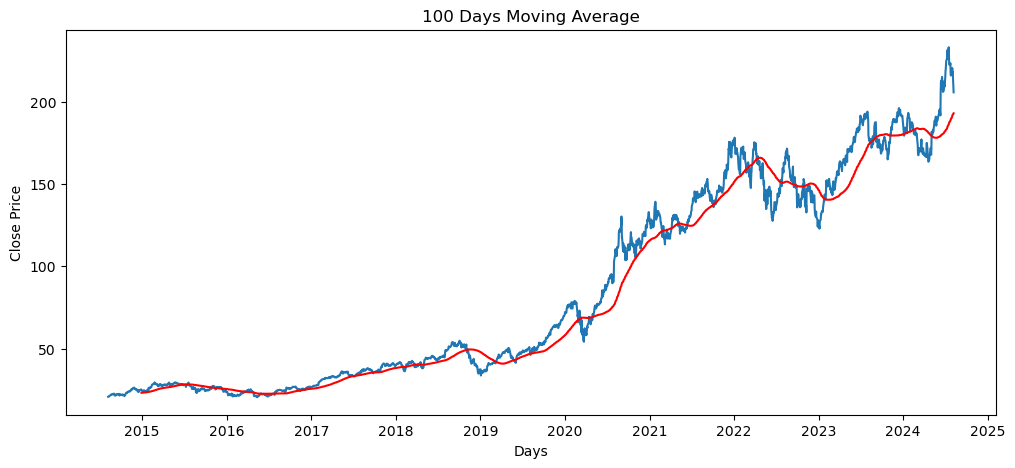

In [74]:

plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.title('100 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Close Price')

200 days Moving Average

In [75]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head(203)

Price,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2014-08-07,20.835508,21.159683,20.751707,20.934745,186844000,NaN,NaN
2014-08-08,20.892849,20.910492,20.570878,20.786996,167460000,NaN,NaN
2014-08-11,21.168497,21.188345,20.914889,21.009717,146340000,NaN,NaN
2014-08-12,21.164085,21.364765,21.084695,21.179522,135180000,NaN,NaN
2014-08-13,21.444164,21.444164,21.179531,21.203789,127664000,NaN,NaN
...,...,...,...,...,...,...,...
2015-05-21,29.337734,29.391324,28.989406,29.042997,158921600,27.329569,NaN
2015-05-22,29.594503,29.690519,29.339956,29.384616,182384000,27.373221,25.326334


Text(0, 0.5, 'Close Price')

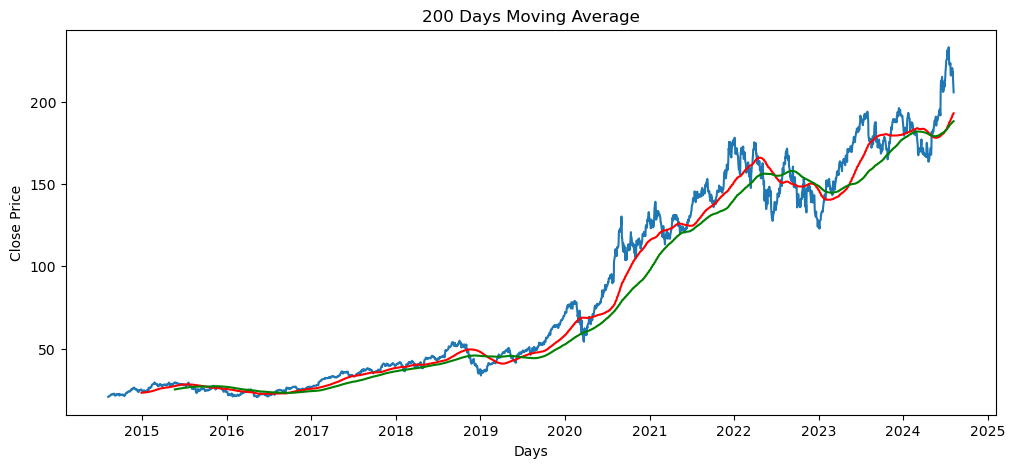

In [76]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.plot(df['MA_200'], 'g')
plt.title('200 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Close Price')

In [77]:
df

Price,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2014-08-07,20.835508,21.159683,20.751707,20.934745,186844000,NaN,NaN
2014-08-08,20.892849,20.910492,20.570878,20.786996,167460000,NaN,NaN
2014-08-11,21.168497,21.188345,20.914889,21.009717,146340000,NaN,NaN
2014-08-12,21.164085,21.364765,21.084695,21.179522,135180000,NaN,NaN
2014-08-13,21.444164,21.444164,21.179531,21.203789,127664000,NaN,NaN
...,...,...,...,...,...,...,...
2024-07-31,220.375595,222.102246,218.936726,219.740508,50036300,191.225299,187.373066
2024-08-01,216.684158,222.757184,215.354446,222.648028,62501000,191.700238,187.572596


### Calculating % changed in each trading session

In [78]:
df['Percentage Changed'] = df.Close.pct_change()
df[['Close', 'Percentage Changed']]

Price,Close,Percentage Changed
Ticker,AAPL,
Date,,
2014-08-07,20.835508,NaN
2014-08-08,20.892849,0.002752
2014-08-11,21.168497,0.013193
2014-08-12,21.164085,-0.000208
2014-08-13,21.444164,0.013234
...,...,...
2024-07-31,220.375595,0.014991
2024-08-01,216.684158,-0.016751


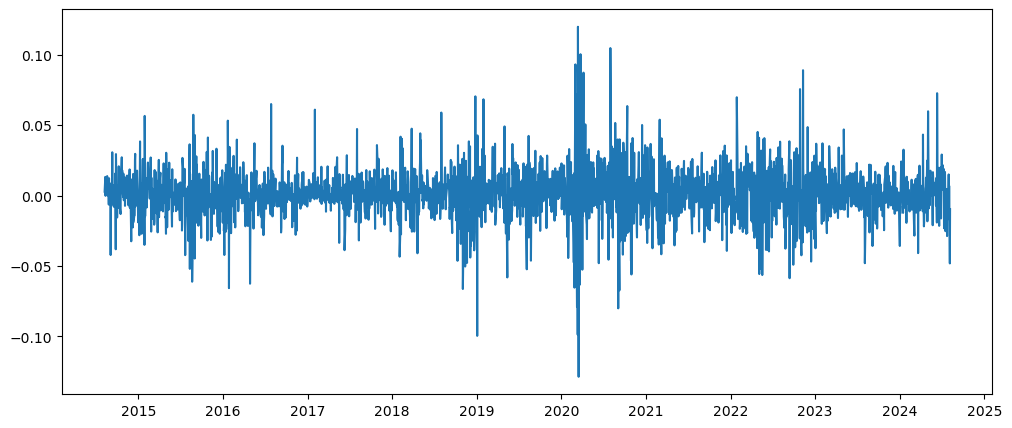

In [79]:
plt.figure(figsize=(12, 5))
plt.plot(df['Percentage Changed'])

# Data Preprocessing

In [80]:
df.shape

(2516, 8)

In [81]:
# Split the data into training and testing datasets
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.70): int(len(df))])
print(data_training)
print(data_testing)

Ticker            AAPL
Date                  
2014-08-07   20.835508
2014-08-08   20.892849
2014-08-11   21.168497
2014-08-12   21.164085
2014-08-13   21.444164
...                ...
2021-07-29  142.093658
2021-07-30  142.308319
2021-08-02  141.976578
2021-08-03  143.771774
2021-08-04  143.371719

[1761 rows x 1 columns]
Ticker            AAPL
Date                  
2021-08-05  143.479080
2021-08-06  142.795105
2021-08-09  142.746262
2021-08-10  142.267471
2021-08-11  142.521500
...                ...
2024-07-31  220.375595
2024-08-01  216.684158
2024-08-02  218.172638
2024-08-05  207.663925
2024-08-06  205.639572

[755 rows x 1 columns]


In [82]:
type(data_training)

pandas.DataFrame

In [83]:
data_training # Data need to be fit to 0 & 1

Ticker,AAPL
Date,
2014-08-07,20.835508
2014-08-08,20.892849
2014-08-11,21.168497
2014-08-12,21.164085
2014-08-13,21.444164
...,...
2021-07-29,142.093658
2021-07-30,142.308319
2021-08-02,141.976578


In [84]:
data_testing

Ticker,AAPL
Date,
2021-08-05,143.479080
2021-08-06,142.795105
2021-08-09,142.746262
2021-08-10,142.267471
2021-08-11,142.521500
...,...
2024-07-31,220.375595
2024-08-01,216.684158
2024-08-02,218.172638


In [85]:
# Scaling down the data between 0 and 1

In [86]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [87]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.00200659],
       [0.00246556],
       [0.00467192],
       ...,
       [0.97165212],
       [0.98602136],
       [0.98281921]], shape=(1761, 1))

In [88]:
type(data_training_array)

numpy.ndarray

In [89]:
data_training_array.shape

(1761, 1)

# 5. Sequence Creation

In [90]:
# 12, 13, 14, 15, 16, 18, 19, 20 # X-train (yesterday price) ---> # 21 (tomorrow price)

In [91]:
x_train = []
y_train = []

# Loop through the data and put it in x-train
for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])
    
x_train, y_train = np.array(x_train), np.array(y_train)

In [92]:
x_train

array([[[0.00200659],
        [0.00246556],
        [0.00467192],
        ...,
        [0.03380727],
        [0.03731743],
        [0.03717561]],

       [[0.00246556],
        [0.00467192],
        [0.00463661],
        ...,
        [0.03731743],
        [0.03717561],
        [0.03471141]],

       [[0.00467192],
        [0.00463661],
        [0.00687844],
        ...,
        [0.03717561],
        [0.03471141],
        [0.03091755]],

       ...,

       [[0.77061232],
        [0.78604841],
        [0.77879808],
        ...,
        [0.96743479],
        [0.97258927],
        [0.97430747]],

       [[0.78604841],
        [0.77879808],
        [0.80187484],
        ...,
        [0.97258927],
        [0.97430747],
        [0.97165212]],

       [[0.77879808],
        [0.80187484],
        [0.81419244],
        ...,
        [0.97430747],
        [0.97165212],
        [0.98602136]]], shape=(1661, 100, 1))

In [93]:
x_train.ndim

3

In [94]:
y_train.ndim

1

In [95]:
x_train.shape

(1661, 100, 1)

In [96]:
y_train.shape

(1661,)

# 6. Model Building

In [97]:
from platform import python_version

print(python_version())

3.11.15


In [98]:
import tensorflow as tf

In [99]:
print(tf.__version__)

2.21.0


In [100]:
# ML Model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [101]:
model = Sequential() # Model that accept the sequence of data. This is for LSTM

# model is the object of the sequential model, will take 100 input and give 1 single prediction output
model.add(Input(shape=(100, 1))) # The first input layer, the shape will expect 100 data with 1 feature (closing price)
model.add(LSTM(units=128, activation='tanh', return_sequences=True)) # relu or tahn, the tahn is important because its get both positive and negative value. Return sequence is to return the full sequence for this layer. So LSTM will produce output for each of the layer
model.add(LSTM(units=64)) # single value, return_sequence will be false by default. So this will return a single output
model.add(Dense(25)) # dense layer, will take the output from previous LSTM layer and analyse in 25 different angle
model.add(Dense(1)) # Will give us a single output

# 7. Model Training

In [ ]:
# Do not run this with VSC, use Jupyter notebook instead
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50) # epoch means we are going through x_train, y_train about 50 times

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0072
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 4.4638e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 4.1395e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 3.8207e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 4.0588e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 3.6276e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 3.5092e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 3.4533e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 3.4736e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 3.5719e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 3.2108e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 2.7894e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 2.8430e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 2.6688e-04
Epoch 15/50
52/52 ━

In [103]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [104]:
# Save the trained model

model.save('stock_prediction_model.keras') # This is to avoid to retrain the model

# 8. Preparing Test Data

In [105]:
data_training

Ticker,AAPL
Date,
2014-08-07,20.835508
2014-08-08,20.892849
2014-08-11,21.168497
2014-08-12,21.164085
2014-08-13,21.444164
...,...
2021-07-29,142.093658
2021-07-30,142.308319
2021-08-02,141.976578


In [106]:
data_testing

Ticker,AAPL
Date,
2021-08-05,143.479080
2021-08-06,142.795105
2021-08-09,142.746262
2021-08-10,142.267471
2021-08-11,142.521500
...,...
2024-07-31,220.375595
2024-08-01,216.684158
2024-08-02,218.172638


In [107]:
past_100_days = data_training.tail(100)

In [108]:
past_100_days

Ticker,AAPL
Date,
2021-03-15,120.765732
2021-03-16,122.304611
2021-03-17,121.515686
2021-03-18,117.395683
2021-03-19,116.869720
...,...
2021-07-29,142.093658
2021-07-30,142.308319
2021-08-02,141.976578


In [110]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df

Ticker,AAPL
0,120.765732
1,122.304611
2,121.515686
3,117.395683
4,116.869720
...,...
850,220.375595
851,216.684158
852,218.172638
853,207.663925


In [113]:
input_data = scaler.fit_transform(final_df)
input_data

array([[3.42721536e-02],
       [4.75114463e-02],
       [4.07241625e-02],
       [5.27894019e-03],
       [7.53974909e-04],
       [2.92443415e-02],
       [2.21217827e-02],
       [1.59189984e-03],
       [5.78172141e-03],
       [1.09769741e-02],
       [1.24853178e-02],
       [0.00000000e+00],
       [1.88537048e-02],
       [2.59761980e-02],
       [5.02766117e-02],
       [5.28744678e-02],
       [6.70357011e-02],
       [8.76491401e-02],
       [1.09771382e-01],
       [9.50229583e-02],
       [1.21753328e-01],
       [1.01643261e-01],
       [1.22340256e-01],
       [1.19491338e-01],
       [1.25189175e-01],
       [1.10693060e-01],
       [1.13960876e-01],
       [1.00888695e-01],
       [1.20831913e-01],
       [1.24183875e-01],
       [1.21418972e-01],
       [1.14631163e-01],
       [1.13793632e-01],
       [9.68668394e-02],
       [1.05916507e-01],
       [6.66168042e-02],
       [6.87116166e-02],
       [8.24541499e-02],
       [8.82457169e-02],
       [6.00427758e-02],


In [114]:
input_data.shape

(855, 1)

In [116]:
# LSTM Model expect data to be in sequential manner

x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

In [117]:
x_test, y_test = np.array(x_test), np.array(y_test)


In [122]:
x_test # sequence of 100 previous value

array([[[3.42721536e-02],
        [4.75114463e-02],
        [4.07241625e-02],
        ...,
        [2.16753379e-01],
        [2.32197820e-01],
        [2.28756066e-01]],

       [[4.75114463e-02],
        [4.07241625e-02],
        [5.27894019e-03],
        ...,
        [2.32197820e-01],
        [2.28756066e-01],
        [2.29679713e-01]],

       [[4.07241625e-02],
        [5.27894019e-03],
        [7.53974909e-04],
        ...,
        [2.28756066e-01],
        [2.29679713e-01],
        [2.23795335e-01]],

       ...,

       [[4.68099615e-01],
        [4.72191834e-01],
        [4.54288228e-01],
        ...,
        [8.63234189e-01],
        [8.91236084e-01],
        [8.59477902e-01]],

       [[4.72191834e-01],
        [4.54288228e-01],
        [4.70230987e-01],
        ...,
        [8.91236084e-01],
        [8.59477902e-01],
        [8.72283595e-01]],

       [[4.54288228e-01],
        [4.70230987e-01],
        [4.66991396e-01],
        ...,
        [8.59477902e-01],
        [8.7228

# 9. Making Prediction

In [123]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


In [124]:
y_predicted

array([[0.2249237 ],
       [0.2261562 ],
       [0.22310303],
       [0.2207041 ],
       [0.21757352],
       [0.21728246],
       [0.23131159],
       [0.24134387],
       [0.25445616],
       [0.25643396],
       [0.23782413],
       [0.22767115],
       [0.23134416],
       [0.24264124],
       [0.2489183 ],
       [0.24511349],
       [0.23782204],
       [0.23864584],
       [0.2611373 ],
       [0.26897356],
       [0.2730521 ],
       [0.2792631 ],
       [0.2852416 ],
       [0.29918906],
       [0.29881683],
       [0.2914654 ],
       [0.26324156],
       [0.2510442 ],
       [0.24196303],
       [0.2430666 ],
       [0.24428532],
       [0.23238684],
       [0.21072899],
       [0.20113066],
       [0.20921749],
       [0.22052419],
       [0.22673826],
       [0.22155488],
       [0.20172329],
       [0.1939227 ],
       [0.18668298],
       [0.18861772],
       [0.176394  ],
       [0.1764846 ],
       [0.18251306],
       [0.19212614],
       [0.19568439],
       [0.195

In [125]:
y_test

array([0.22967971, 0.22379534, 0.22337513, 0.219256  , 0.22144145,
       0.24691277, 0.24867815, 0.26565876, 0.25784137, 0.22564486,
       0.22850284, 0.24102839, 0.25380599, 0.25304906, 0.24245758,
       0.23556422, 0.24447487, 0.28247108, 0.27162755, 0.27734337,
       0.28692654, 0.29239084, 0.31248122, 0.29919991, 0.2904573 ,
       0.24758529, 0.25246082, 0.24043989, 0.24808938, 0.24607196,
       0.22312295, 0.19689536, 0.2010141 , 0.2213577 , 0.22959596,
       0.2303521 , 0.21732272, 0.18823663, 0.19597053, 0.18478988,
       0.19445733, 0.16495142, 0.18151183, 0.18899329, 0.19983748,
       0.19655903, 0.1958025 , 0.18487429, 0.17983047, 0.20378832,
       0.212867  , 0.22724208, 0.24581991, 0.25002332, 0.25187245,
       0.24523154, 0.2448112 , 0.25052741, 0.24657644, 0.27784786,
       0.25456213, 0.24750101, 0.25641166, 0.26876918, 0.26431386,
       0.26885963, 0.26178827, 0.26490275, 0.24057326, 0.24015253,
       0.25799969, 0.25808383, 0.26650246, 0.28746477, 0.32433

In [126]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten() # Convert back to original state
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten() # Both will be in the same shape

In [ ]:
y_predicted # This is the predicted price

array([142.92625 , 143.06952 , 142.71463 , 142.43579 , 142.07191 ,
       142.03807 , 143.66876 , 144.83487 , 146.359   , 146.58888 ,
       144.42575 , 143.24562 , 143.67255 , 144.98567 , 145.7153  ,
       145.27304 , 144.4255  , 144.52127 , 147.13557 , 148.04643 ,
       148.52051 , 149.24243 , 149.93736 , 151.55855 , 151.51529 ,
       150.6608  , 147.38017 , 145.9624  , 144.90685 , 145.03511 ,
       145.17677 , 143.79375 , 141.27632 , 140.16066 , 141.10063 ,
       142.41489 , 143.13718 , 142.53468 , 140.22954 , 139.32283 ,
       138.48132 , 138.7062  , 137.28539 , 137.29591 , 137.99663 ,
       139.114   , 139.5276  , 139.53357 , 138.79152 , 137.99706 ,
       139.0283  , 140.41862 , 142.03513 , 143.97159 , 145.16628 ,
       145.6693  , 145.33675 , 145.01744 , 145.25172 , 145.22672 ,
       147.18245 , 146.90092 , 145.95248 , 145.96596 , 146.91516 ,
       147.21068 , 147.51884 , 147.18217 , 147.11783 , 145.57448 ,
       144.63779 , 145.4545  , 146.13664 , 146.96422 , 148.687

In [128]:
y_test # The original price

array([143.4790802 , 142.79510498, 142.7462616 , 142.26747131,
       142.52149963, 145.48217773, 145.68737793, 147.66113281,
       146.75247192, 143.01008606, 143.34228516, 144.79820251,
       146.28341675, 146.19543457, 144.96432495, 144.16307068,
       145.19880676, 149.61532593, 148.35491943, 149.01930237,
       150.13320923, 150.76835632, 153.10357666, 151.55981445,
       150.54360962, 145.56034851, 146.12705994, 144.72979736,
       145.61894226, 145.38444519, 142.71694946, 139.66836548,
       140.14710999, 142.51176453, 143.46934509, 143.55723572,
       142.04275513, 138.66191101, 139.56086731, 138.26127625,
       139.38497925, 135.95533752, 137.88024902, 138.74986267,
       140.01034546, 139.62927246, 139.54133606, 138.27108765,
       137.68481445, 140.46957397, 141.52484131, 143.19573975,
       145.35514832, 145.84373474, 146.05867004, 145.28675842,
       145.23789978, 145.90232849, 145.44308472, 149.07794189,
       146.37130737, 145.55055237, 146.58628845, 148.02

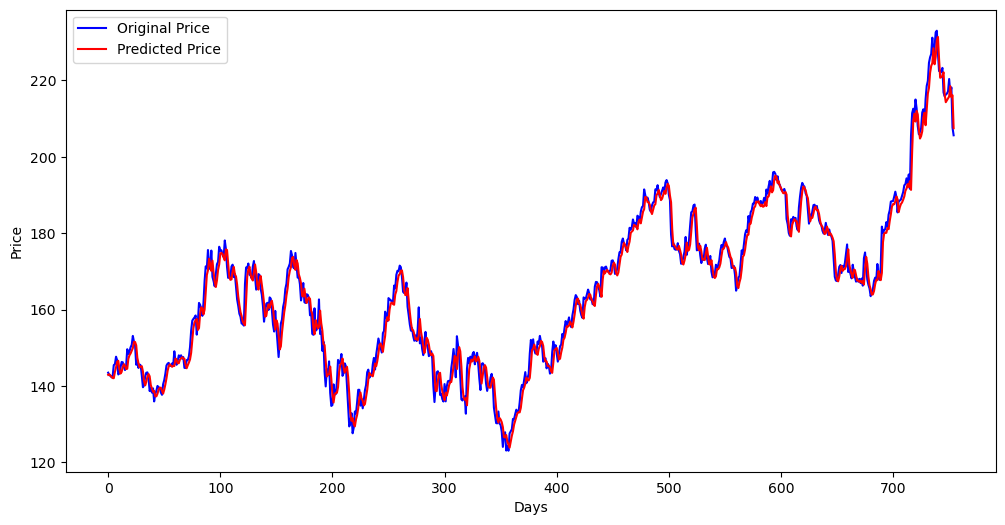

In [133]:
# Plot the graph so easier to visualize
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

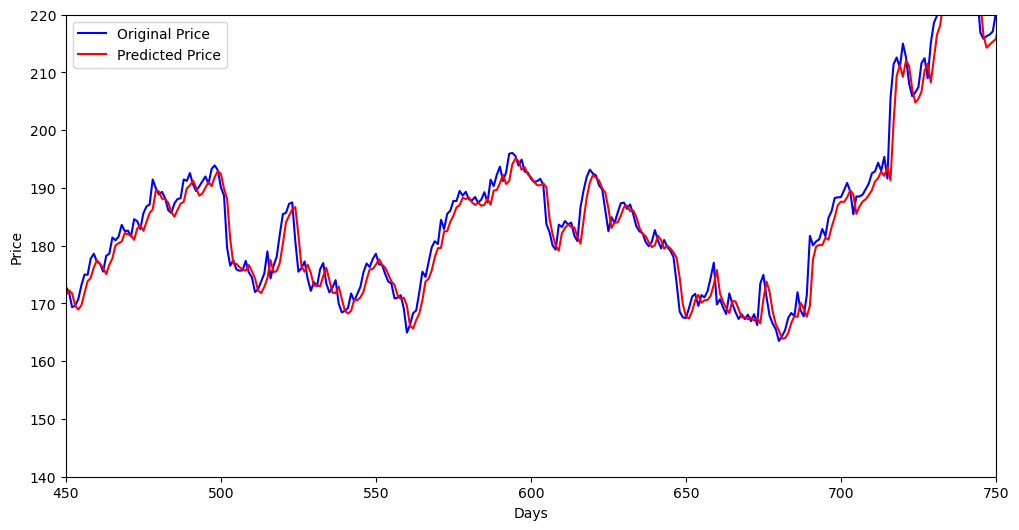

In [ ]:
# Zoom in plot
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(450, 750) # To zoom in 450 to 750
plt.ylim(140, 220) # To zoom in 140,220
plt.show() # The result looks good based on the 30% of our data. Will not be 100% accurate

# 10. Model Evaluation

In [138]:
# Mean Squared Error (MSE) - Lower is better
# To measure the average difference between predicted with the original plot

from sklearn.metrics import mean_squared_error, r2_score

In [139]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean squared Error(MSE): {mse}") # 9.35 is pretty good because some model will have high value like 500

Mean squared Error(MSE): 9.354884774868827


In [140]:
# Root mean squared error (RMSE) - Lower is better
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}") # By average the prediction is off by 3.05$

Root Mean Squared Error (RMSE): 3.0585756120895273


In [141]:
# R-Squared - How the predicted actually match the predicted
r2 = r2_score(y_test, y_predicted)
print(f"R-Squared: {r2}") # If close to 1 then the prediction is good, if 0 then it is bad


R-Squared: 0.9791920239782144
